In [2]:
# Starting with streaming the response from the LLM
# stream() is the fundamental method we use for streaming the output,
# astream() is used for streaming output asynchronously.
# stream and astream both gives chunks out in the output, but using astream_events() you can get each and every
# token an LLM is generating along with other metadata.

# metadata like:
# event, name, data, metadata.



from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages, MessagesState
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image

model = ChatGoogleGenerativeAI(model="gemini-flash-latest", temperature=0.7, max_retries = 2)

In [3]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
model = ChatGroq(model = "qwen/qwen3-32b")

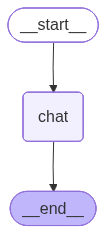

In [4]:

def chat_node(state: MessagesState):
    """Simple node that streams the model output"""
    # Use stream() instead of invoke() to get token-by-token output
    full_message = ""
    for chunk in model.stream(state["messages"]):
        full_message += chunk.content
        print(chunk.content, end="", flush=True)
    
    # Import AIMessage to construct the response
    from langchain_core.messages import AIMessage
    return {"messages": AIMessage(content=full_message)}

# Build the graph
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# Test the agent
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": HumanMessage(content="Hi, what is your name?")})


<think>
Okay, the user is asking for my name. I need to provide a clear and friendly response.

I should mention both my official name, Qwen, and the name in English, which is Tongyi Qianwen (Qwen). 

I should keep the response concise and conversational, avoiding any technical jargon or overly formal language. 

I should make sure to invite them to ask more questions or share their needs. 

This is straightforward and aligns with the user's request. I'll proceed with this approach.
</think>

Hello! My name is Qwen, also known as Tongyi Qianwen in English. I'm a large language model developed by Tongyi Lab. How can I assist you today? Feel free to ask me any questions or let me know if you need help with anything! 😊

In [6]:

# Print the response
for m in response["messages"]:
    m.pretty_print()


================================ Human Message =================================

Hi, what is your name?
================================== Ai Message ==================================

<think>
Okay, the user is asking for my name. I need to provide a clear and friendly response.

I should mention both my official name, Qwen, and the name in English, which is Tongyi Qianwen (Qwen). 

I should keep the response concise and conversational, avoiding any technical jargon or overly formal language. 

I should make sure to invite them to ask more questions or share their needs. 

This is straightforward and aligns with the user's request. I'll proceed with this approach.
</think>

Hello! My name is Qwen, also known as Tongyi Qianwen in English. I'm a large language model developed by Tongyi Lab. How can I assist you today? Feel free to ask me any questions or let me know if you need help with anything! 😊


In [7]:
# now using stream instead of graph.invoke()

for chunk in graph.stream({"messages": HumanMessage(content="Tell me some interesting things about Chinese culture, under 10 lines.")}, config):
    print(chunk.get("chat"))


<think>
Okay, the user wants some interesting things about Chinese culture in under 10 lines. Let me start by thinking about the key elements that define Chinese culture. There's the rich history with dynasties like the Tang and Han. Maybe mention the Great Wall and the Terracotta Army.

I should include festivals, like the Chinese New Year and Mid-Autumn Festival. The dragon and phoenix symbols are important, as well as the concept of yin and yang. Traditional arts like calligraphy and Peking opera come to mind. Also, Confucianism's influence on values like filial piety.

Wait, the user might be interested in both ancient and modern aspects. Maybe touch on tea culture and martial arts like kung fu. Need to keep it concise, so each point should be a single line. Let me count: Great Wall, Terracotta Army, festivals, symbols, calligraphy, Confucianism, tea, kung fu. That's eight points. Maybe add something about cuisine? But the user asked for under 10 lines, so perhaps stick to eight. C

In [8]:

# Stream and print full message content
print("\n=== Streaming Full Messages ===\n")
for chunk in graph.stream({"messages": HumanMessage(content="What is machine learning?")}, config):
    if "chat" in chunk:
        messages = chunk["chat"]["messages"]
        if isinstance(messages, list):
            for msg in messages:
                print(f"{msg.content}", end="", flush=True)
        else:
            print(f"{messages.content}", end="", flush=True)
print("\n")



=== Streaming Full Messages ===

<think>
Okay, so I need to figure out what machine learning is. Let me start by recalling what I know. I've heard the term before, probably in the context of AI. But I'm not exactly sure how it works. Maybe it's when computers learn from data instead of being programmed explicitly? That sounds familiar. 

Wait, machine learning is a subset of AI, right? So AI is the bigger picture, and machine learning is a part of that. But how exactly does machine learning work? I remember something about algorithms that can improve with experience. Like, instead of writing code that tells the computer what to do step by step, you feed it data, and it learns patterns from that data.

There are different types of machine learning. I think there's supervised learning, where the algorithm is trained on labeled data. For example, if you want a computer to recognize images of cats, you give it a bunch of images that are already labeled as cat or not cat. The algorithm lea

In [9]:

# Using astream_events for token-level streaming
import asyncio
async for chunk in graph.astream_events({"messages" : "Tell me about the various Moons of Jupyter."}, config):
    print(chunk)


{'event': 'on_chain_start', 'data': {'input': {'messages': 'Tell me about the various Moons of Jupyter.'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e97d8-757b-7e43-8f8a-1f89d4e2fc3c', 'metadata': {'thread_id': '1', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Tell me about the various Moons of Jupyter.', additional_kwargs={}, response_metadata={}, id='4c005814-61f3-40c5-8250-6c702c4ce155')]}}, 'name': 'chat', 'tags': ['graph:step:1'], 'run_id': '019e97d8-757d-73e0-bd92-dcadbacb581b', 'metadata': {'thread_id': '1', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'chat', 'langgraph_triggers': ('branch:to:chat',), 'langgraph_path': ('__pregel_pull', 'chat'), 'langgraph_checkpoint_ns': 'chat:bc08d06b-bdb8-e659-b171-82ccfb46313c'}, 'parent_ids': ['019e97d8-757b-7e43-8f8a-1f89d4e2fc3c']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Tel

In [10]:
## BREAKPOINTS
# these are used for Human in the loop interference.
# these have various use cases, such as 
# Approval
# Debugging
# Editing the state.

# The first example is from # Approval for a particular node, like the Tool Node.
# Looking on static interruption first, when you know at which point you need to introduce the interruption.


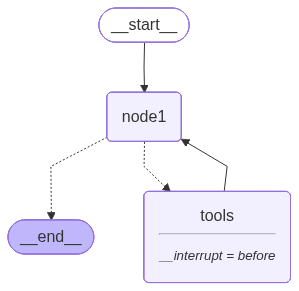

In [11]:
from langchain_core.tools import tool


model = ChatGoogleGenerativeAI(model = "gemini-flash-latest", temperature = 0.7)
system_prompt = """ 
You are a helpful calculating AI assistant which can make use of the available tools
"""
@tool 
def multiply(a: int, b: int)-> int:
    """ Multiply two variable of int data type 
    a: int 
    b: int
    the output will also be an integer.
    """

    return int(a*b)

tools = [multiply]
model = model.bind_tools(tools)

def calling_node(state:MessagesState):
    """ Use this for calling the llm"""
    return {"messages": [model.invoke(state["messages"])]}


from langgraph.prebuilt import ToolNode, tools_condition
builder = StateGraph(MessagesState)
builder.add_node("node1", calling_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "node1")
builder.add_conditional_edges("node1", tools_condition)
builder.add_edge("tools", "node1")

memory = MemorySaver()

graph = builder.compile(interrupt_before=["tools"], checkpointer= memory)

from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
config = {"configurable": {"thread_id": 1}}

for chunk in graph.stream({"messages": "What is the product of 2 and 3"}, config):
    print(chunk)

{'node1': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'20e7535c-3b89-41c6-b0fe-9a03960470ee': 'EsgCCsUCAQw51sfjrDVTykGkP9V6RV+cku/XROTL1rMIPyhfPNXogOjkwa16gCV7K90xYuhTE07+7lqSFikcdVhJfYij3KcLLp2ScW0nNOiuf/MnPNdNcFuNnKYoqQo/ooz9O5n2Torm1WzvEIgTq6ctz4nHGPX9MJe30HZcO697re84T7eSKBfi6wcag8rjYjVkMXyJZi4aGTTqsA9aayK2tN+RAOKUAT+QlIHVEsDLX3fh9qH53phrHSXjJph53A6XBzipF7X+iD/AGcbXDkwfo1vl6bDtMt4pDTmZ4ZzZv9XAB/Rrc5S8mxhda/t/4yr/GVffqpKFwvs8p8E8Wk2s4BZiSG+7NrODLbHrRGk7ak1qxnJC73pdu8ljiHthNI4pnOgvhh5Hy6GCI3iI3hErzXB4Vtfn5AXcEZwdxhUlssI/lpTeuZL82w=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e97d8-ae35-7342-8c5c-e120b1b9ae40-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '20e7535c-3b89-41c6-b0fe-9a03960470ee', 'type': 'tool_call'}], invalid_t

In [14]:
# the next node to call is tools as it was interrupted.
graph.get_state(config).next

('tools',)

In [15]:
# now, to continue the graph execution, we will :

for chunk in graph.stream(None, config):
    print(chunk)

# this makes the graph continue it's execution, as it didn't recieve any input for the thread present in a given config.

{'tools': {'messages': [ToolMessage(content='6', name='multiply', id='17e63875-ec49-40f0-8718-28b78a697b47', tool_call_id='20e7535c-3b89-41c6-b0fe-9a03960470ee')]}}
{'node1': {'messages': [AIMessage(content=[{'type': 'text', 'text': 'The product of 2 and 3 is 6.', 'extras': {'signature': 'EjQKMgEMOdbHRuw1WOn2FYGWsPjxEhyxd1l+HYRR/WM3zB9oPDd5d0m7y7T6GqKuM+c+zjpF'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e97d9-be41-7170-a655-197c4a438c9e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 187, 'output_tokens': 12, 'total_tokens': 199, 'input_token_details': {'cache_read': 0}})]}}


In [16]:
# next example would be editing the state.
message = HumanMessage(content = "I want to know about Lunar Eclipse.")
for chunk in graph.stream({"messages": message}, config):
    print(chunk)

{'node1': {'messages': [AIMessage(content=[{'type': 'text', 'text': 'A **lunar eclipse** occurs when the Earth moves directly between the Sun and the Moon, casting its shadow onto the Moon. This can only happen during a **full moon** phase, when the Moon is opposite the Sun in our sky.\n\nHere are the key aspects of a lunar eclipse:\n\n### 1. How It Works\nThe Earth casts two types of shadows:\n*   **Umbra:** The dark, inner part of the shadow where all sunlight is blocked.\n*   **Penumbra:** The lighter, outer part of the shadow where only some sunlight is blocked.\n\n### 2. Types of Lunar Eclipses\nDepending on how the Sun, Earth, and Moon align, there are three types of eclipses:\n*   **Total Lunar Eclipse:** The entire Moon passes through the Earth\'s dark umbral shadow. During a total eclipse, the Moon doesn\'t go completely dark; instead, it often turns a reddish-orange color. This is sometimes called a **"Blood Moon."**\n*   **Partial Lunar Eclipse:** Only a portion of the Moon 

In [17]:
message = HumanMessage(content = "What would be the product of 72 and 34")

graph.invoke({"messages": message}, config)

{'messages': [HumanMessage(content='What is the product of 2 and 3', additional_kwargs={}, response_metadata={}, id='6b81a415-3121-49d9-b110-447f14696c4e'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'20e7535c-3b89-41c6-b0fe-9a03960470ee': 'EsgCCsUCAQw51sfjrDVTykGkP9V6RV+cku/XROTL1rMIPyhfPNXogOjkwa16gCV7K90xYuhTE07+7lqSFikcdVhJfYij3KcLLp2ScW0nNOiuf/MnPNdNcFuNnKYoqQo/ooz9O5n2Torm1WzvEIgTq6ctz4nHGPX9MJe30HZcO697re84T7eSKBfi6wcag8rjYjVkMXyJZi4aGTTqsA9aayK2tN+RAOKUAT+QlIHVEsDLX3fh9qH53phrHSXjJph53A6XBzipF7X+iD/AGcbXDkwfo1vl6bDtMt4pDTmZ4ZzZv9XAB/Rrc5S8mxhda/t/4yr/GVffqpKFwvs8p8E8Wk2s4BZiSG+7NrODLbHrRGk7ak1qxnJC73pdu8ljiHthNI4pnOgvhh5Hy6GCI3iI3hErzXB4Vtfn5AXcEZwdxhUlssI/lpTeuZL82w=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e97d8-ae35-7342-8c5c-e120b1b9ae40-0', to

In [18]:
graph.get_state(config).next
# here we will try to modify the 

('tools',)

In [22]:
from pprint import pprint
pprint(graph.get_state(config).values)



{'messages': [HumanMessage(content='What is the product of 2 and 3', additional_kwargs={}, response_metadata={}, id='6b81a415-3121-49d9-b110-447f14696c4e'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'20e7535c-3b89-41c6-b0fe-9a03960470ee': 'EsgCCsUCAQw51sfjrDVTykGkP9V6RV+cku/XROTL1rMIPyhfPNXogOjkwa16gCV7K90xYuhTE07+7lqSFikcdVhJfYij3KcLLp2ScW0nNOiuf/MnPNdNcFuNnKYoqQo/ooz9O5n2Torm1WzvEIgTq6ctz4nHGPX9MJe30HZcO697re84T7eSKBfi6wcag8rjYjVkMXyJZi4aGTTqsA9aayK2tN+RAOKUAT+QlIHVEsDLX3fh9qH53phrHSXjJph53A6XBzipF7X+iD/AGcbXDkwfo1vl6bDtMt4pDTmZ4ZzZv9XAB/Rrc5S8mxhda/t/4yr/GVffqpKFwvs8p8E8Wk2s4BZiSG+7NrODLbHrRGk7ak1qxnJC73pdu8ljiHthNI4pnOgvhh5Hy6GCI3iI3hErzXB4Vtfn5AXcEZwdxhUlssI/lpTeuZL82w=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e97d8-ae35-7342-8c5c-e120b1b

In [30]:
# Get the current state before updating
current_state = graph.get_state(config)
print("State before update:")
pprint(current_state.values)

# Modify the messages - add an approval/modification message
from langchain_core.messages import AIMessage
updated_messages = current_state.values["messages"] + [AIMessage(content="[APPROVED] Executing the multiply tool")]

# Update the state with new values
graph.update_state(config, {"messages": updated_messages})

print("\nState after update:")
pprint(graph.get_state(config).values)


State before update:
{'messages': [HumanMessage(content='What is the product of 2 and 3', additional_kwargs={}, response_metadata={}, id='6b81a415-3121-49d9-b110-447f14696c4e'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 3}'}, '__gemini_function_call_thought_signatures__': {'20e7535c-3b89-41c6-b0fe-9a03960470ee': 'EsgCCsUCAQw51sfjrDVTykGkP9V6RV+cku/XROTL1rMIPyhfPNXogOjkwa16gCV7K90xYuhTE07+7lqSFikcdVhJfYij3KcLLp2ScW0nNOiuf/MnPNdNcFuNnKYoqQo/ooz9O5n2Torm1WzvEIgTq6ctz4nHGPX9MJe30HZcO697re84T7eSKBfi6wcag8rjYjVkMXyJZi4aGTTqsA9aayK2tN+RAOKUAT+QlIHVEsDLX3fh9qH53phrHSXjJph53A6XBzipF7X+iD/AGcbXDkwfo1vl6bDtMt4pDTmZ4ZzZv9XAB/Rrc5S8mxhda/t/4yr/GVffqpKFwvs8p8E8Wk2s4BZiSG+7NrODLbHrRGk7ak1qxnJC73pdu8ljiHthNI4pnOgvhh5Hy6GCI3iI3hErzXB4Vtfn5AXcEZwdxhUlssI/lpTeuZL82w=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e97d8-a